# Center-Pivot Alfalfa — Multi-Zone NDVI Timeseries & Canopy Height

**Location**:  
**Imagery**: PlanetScope PSScene 4-band Analytic Surface Reflectance (`analytic_sr`)  
**Period**:   
**Sensor**: PSB.SD  |  Band 1=Blue, Band 2=Green, Band 3=Red, Band 4=NIR  |  3 m pixels

---

## Workflow
1. Load management zones from a multi-feature GeoJSON (I've been projecting to UTM Zone 12N)
2. Rasterise each zone polygon onto the Planet image grid
3. For each scene: compute NDVI, apply UDM2 quality mask, extract per-zone statistics
4. When multiple scenes share a date, keep the one with the most valid pixels per zone
5. Estimate alfalfa canopy height from NDVI (empirical linear model)
6. Visualise timeseries and export results to CSV

## Alfalfa Height Model
```
H_cm = max(0,  HEIGHT_SLOPE × NDVI + HEIGHT_INTERCEPT)
```
Default: `HEIGHT_SLOPE = 100`, `HEIGHT_INTERCEPT = -10`  
Calibrated to alfalfa regrowth literature (Zhao et al. 2007; Rasmussen et al. 2016).
Tune these in the **Configuration** cell if field measurements are available.

In [1]:
stationid = 'US-UTJ'

## 1 · Imports

In [2]:
import json
import re
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection

import rasterio
import rasterio.features
from pyproj import Transformer

warnings.filterwarnings('ignore', category=RuntimeWarning)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')

Imports OK


## 2 · Configuration
Edit paths and model parameters here.

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
# Directory that contains the *_composite.tif and *_udm2.tif files
DATA_DIR = Path(f"C:\\Users\\dmenuz\\Downloads\\{stationid}")       

# GeoJSON with one Feature per management zone (WGS84 / EPSG:4326)
GEOJSON_PATH = Path(f"C:\\Users\\dmenuz\\Downloads\\{stationid}_crop_zones_two.geojson")

# Output directory for CSV and figures
OUTPUT_DIR = Path('.')

# ── Planet band indices (1-based) ──────────────────────────────────────────────
BAND_BLUE  = 1
BAND_GREEN = 2
BAND_RED   = 3
BAND_NIR   = 4

# SR scale: analytic_sr DN → reflectance (0–1)
SR_SCALE = 1e-4

# ── UDM2 quality bands (1-based) ──────────────────────────────────────────────
UDM2_CLEAR      = 1   # 1 = clear pixel
UDM2_CONFIDENCE = 7   # 0–100
CONFIDENCE_MIN  = 70  # minimum acceptable confidence

# ── Alfalfa height model: H_cm = slope * NDVI + intercept ─────────────────────
HEIGHT_SLOPE      = 100.0   # cm per NDVI unit
HEIGHT_INTERCEPT  = -10.0   # cm
HEIGHT_MIN_CM     = 0.0
HEIGHT_MAX_CM     = 100.0

# ── Zone colour palette (one colour per zone) ──────────────────────────────────
ZONE_COLORS = {
    'NW' : '#1565c0',   # blue
    'NE' : '#2e7d32',   # green
    'SW' : '#e65100',   # orange
    'SES': '#b71c1c',   # red
    'ESE': '#6a1b9a',   # purple
}
DEFAULT_COLOR = '#546e7a'  # fallback for unnamed zones

print('Configuration OK')

Configuration OK


## 3 · Helper Functions

In [4]:
def ndvi_from_bands(red: np.ndarray, nir: np.ndarray) -> np.ndarray:
    """Compute NDVI; returns NaN where denom is 0 or pixels are nodata (=0)."""
    denom = nir + red
    with np.errstate(invalid='ignore', divide='ignore'):
        ndvi = np.where(denom > 0, (nir - red) / denom, np.nan)
    ndvi = np.where((red == 0) & (nir == 0), np.nan, ndvi)  # nodata mask
    return ndvi.astype(np.float32)


def height_from_ndvi(ndvi: np.ndarray) -> np.ndarray:
    """Empirical linear NDVI → alfalfa canopy height (cm)."""
    return np.clip(HEIGHT_SLOPE * ndvi + HEIGHT_INTERCEPT,
                   HEIGHT_MIN_CM, HEIGHT_MAX_CM)


def zone_stats(ndvi_vals: np.ndarray) -> dict:
    """Compute summary statistics for a 1-D array of NDVI values."""
    h = height_from_ndvi(ndvi_vals)
    return {
        'ndvi_mean'       : float(np.mean(ndvi_vals)),
        'ndvi_median'     : float(np.median(ndvi_vals)),
        'ndvi_std'        : float(np.std(ndvi_vals)),
        'ndvi_p25'        : float(np.percentile(ndvi_vals, 25)),
        'ndvi_p75'        : float(np.percentile(ndvi_vals, 75)),
        'ndvi_min'        : float(np.nanmin(ndvi_vals)),
        'ndvi_max'        : float(np.nanmax(ndvi_vals)),
        'height_mean_cm'  : float(np.mean(h)),
        'height_median_cm': float(np.median(h)),
        'height_p25_cm'   : float(np.percentile(h, 25)),
        'height_p75_cm'   : float(np.percentile(h, 75)),
    }


def collect_scenes(data_dir: Path) -> dict:
    """Return dict keyed by 'YYYY-MM-DD_stripID' → {date, tif, udm2}."""
    pattern = re.compile(r'(\d{4}-\d{2}-\d{2})_strip_(\d+)_composite\.tif$')
    scenes = {}
    for p in sorted(data_dir.glob('*_composite.tif')):
        m = pattern.match(p.name)
        if not m:
            continue
        date_str, strip_id = m.groups()
        udm2 = p.with_name(p.name.replace('_composite.tif', '_composite_udm2.tif'))
        if not udm2.exists():
            continue
        scenes[f'{date_str}_{strip_id}'] = {
            'date': datetime.strptime(date_str, '%Y-%m-%d'),
            'tif' : p,
            'udm2': udm2,
        }
    return scenes


print('Functions defined')

Functions defined


## 4 · Load GeoJSON Zones & Build Pixel Masks

In [5]:
import json
import rasterio
import rasterio.features
import numpy as np

# Load GeoJSON
with open(GEOJSON_PATH) as f:
    gj = json.load(f)

features = gj['features']
print(f'Loaded {len(features)} zone features from {GEOJSON_PATH.name}')

# Use the first available scene to obtain raster grid parameters
scenes = collect_scenes(DATA_DIR)
ref_tif = next(iter(scenes.values()))['tif']
print(f'Reference raster : {ref_tif.name}')

with rasterio.open(ref_tif) as src:
    raster_crs   = src.crs.to_epsg()
    raster_shape = (src.height, src.width)
    transform    = src.transform
    pixel_m      = abs(transform.a)   # pixel size in metres

print(f'Raster grid      : {raster_shape[1]} × {raster_shape[0]} px  ({pixel_m:.0f} m resolution)')
print(f'CRS              : EPSG:{raster_crs}')

# REMOVED: xformer (No longer needed since coordinates are already UTM)
inv_transform = ~transform   # pixel-space inverse

# Build per-zone masks and metadata
zones = {}   # zone_name → {'mask', 'poly_px', 'area_ha', 'feature_id'}

# Added 'enumerate' to give unique names if 'quad' or 'id' are missing
for i, feat in enumerate(features):
    props        = feat['properties']
    
    # Dynamic naming prevents features from overwriting each other
    zone_name    = str(props.get('quad') or props.get('id') or f'zone_{i+1}')
    feature_id   = props.get('id')
    
    # Directly reading coordinates as UTM
    coords_utm   = feat['geometry']['coordinates'][0]   

    # Area via shoelace formula (works perfectly with UTM meters)
    xs = np.array([c[0] for c in coords_utm])
    ys = np.array([c[1] for c in coords_utm])
    area_ha = 0.5 * abs(np.dot(xs, np.roll(ys, -1)) - np.dot(ys, np.roll(xs, -1))) / 1e4

    # Polygon in pixel space (col, row) — used for matplotlib plotting
    poly_px = [inv_transform * (x, y) for x, y in coords_utm]

    # Rasterise
    geom_utm = {'type': 'Polygon', 'coordinates': [coords_utm]}
    mask = rasterio.features.geometry_mask(
        [geom_utm],
        out_shape=raster_shape,
        transform=transform,
        invert=True,
    )

    zones[zone_name] = {
        'mask'      : mask,
        'poly_px'   : poly_px,
        'area_ha'   : area_ha,
        'feature_id': feature_id,
        'n_pixels'  : int(mask.sum()),
    }

# Also build a combined 'ALL' mask (union of all zones)
all_mask = np.zeros(raster_shape, dtype=bool)
for z in zones.values():
    all_mask |= z['mask']

print(f'\nZone summary:')
print(f'{"Zone":<8} {"Pixels":>8} {"Area (ha)":>10}')
print('-' * 30)
for name, z in zones.items():
    print(f'{name:<8} {z["n_pixels"]:>8,} {z["area_ha"]:>10.1f}')
print('-' * 30)
total_ha = sum(z['area_ha'] for z in zones.values())
print(f'{"TOTAL":<8} {all_mask.sum():>8,} {total_ha:>10.1f}')

Loaded 2 zone features from US-UTJ_crop_zones_two.geojson
Reference raster : 2024-01-16_strip_7044936_composite.tif
Raster grid      : 335 × 292 px  (3 m resolution)
CRS              : EPSG:32612

Zone summary:
Zone       Pixels  Area (ha)
------------------------------
W          11,048       10.0
E          10,926        9.8
------------------------------
TOTAL      21,974       19.8


## 5 · Preview Zone Layout

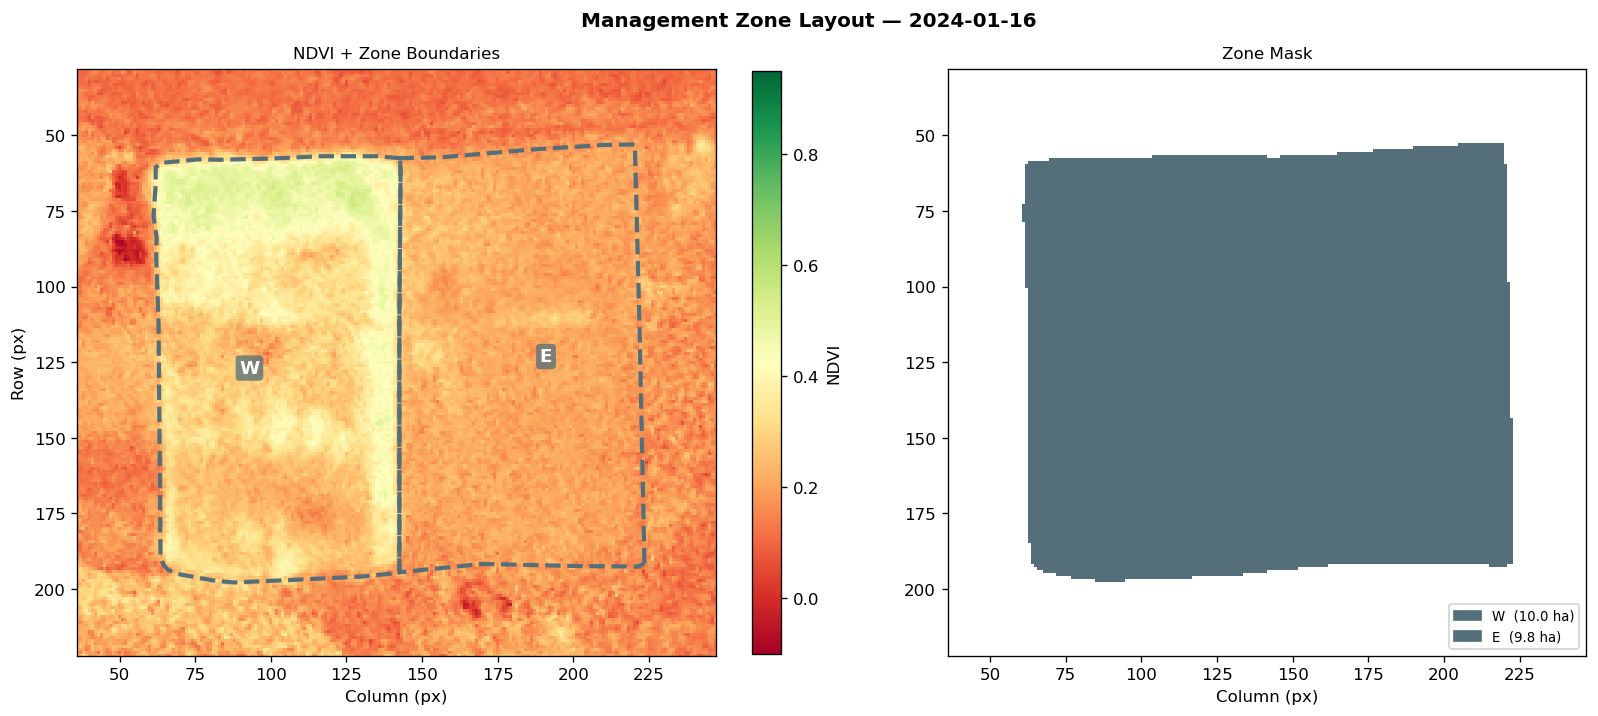

Zone layout saved → zone_layout.png


In [6]:
# Display zone layout over the peak-season NDVI image
# Find the scene with highest NDVI (will be refined after full processing)
peak_tif = DATA_DIR / '2023-06-05_strip_6558281_composite.tif'
if not peak_tif.exists():
    peak_tif = next(iter(scenes.values()))['tif']

with rasterio.open(peak_tif) as src:
    red_b = src.read(BAND_RED).astype(np.float32)
    nir_b = src.read(BAND_NIR).astype(np.float32)

ndvi_map = ndvi_from_bands(red_b, nir_b)

# Bounding box around all zones with margin
rows_all, cols_all = np.where(all_mask)
margin = 25
r0 = max(0, rows_all.min() - margin);  r1 = min(raster_shape[0], rows_all.max() + margin)
c0 = max(0, cols_all.min() - margin);  c1 = min(raster_shape[1], cols_all.max() + margin)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Management Zone Layout — ' + peak_tif.name[:10], fontsize=12, fontweight='bold')

# Left: NDVI image with zone boundaries
ax = axes[0]
im = ax.imshow(ndvi_map, cmap='RdYlGn', vmin=-0.1, vmax=0.95)
for name, z in zones.items():
    col = ZONE_COLORS.get(name, DEFAULT_COLOR)
    arr = np.array(z['poly_px'])   # (col, row)
    patch = mpatches.Polygon(arr, closed=True, fill=False,
                              edgecolor=col, linewidth=2.5, linestyle='--')
    ax.add_patch(patch)
    # Label at centroid
    cx = np.mean(arr[:, 0]);  cy = np.mean(arr[:, 1])
    ax.text(cx, cy, name, color='white', fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc=col, alpha=0.75, lw=0))
plt.colorbar(im, ax=ax, fraction=0.04, label='NDVI')
ax.set_xlim(c0, c1);  ax.set_ylim(r1, r0)
ax.set_title('NDVI + Zone Boundaries', fontsize=10)
ax.set_xlabel('Column (px)');  ax.set_ylabel('Row (px)')

# Right: colour-filled zone map
ax2 = axes[1]
zone_label_img = np.zeros(raster_shape, dtype=np.float32)
zone_names_list = list(zones.keys())
for i, (name, z) in enumerate(zones.items(), 1):
    zone_label_img[z['mask']] = i

# Custom colormap from zone colours
cmap_colors = ['#ffffff'] + [ZONE_COLORS.get(n, DEFAULT_COLOR) for n in zone_names_list]
zone_cmap = mcolors.ListedColormap(cmap_colors)
ax2.imshow(zone_label_img, cmap=zone_cmap, vmin=0, vmax=len(zones), interpolation='nearest')
ax2.set_xlim(c0, c1);  ax2.set_ylim(r1, r0)
ax2.set_title('Zone Mask', fontsize=10)
ax2.set_xlabel('Column (px)')

# Legend
handles = [mpatches.Patch(color=ZONE_COLORS.get(n, DEFAULT_COLOR),
                           label=f'{n}  ({zones[n]["area_ha"]:.1f} ha)')
           for n in zone_names_list]
ax2.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{stationid}_zone_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zone layout saved → zone_layout.png')

## 6 · Process All Scenes
For each composite scene: apply UDM2 mask, compute NDVI, extract per-zone statistics.

In [7]:
## original- doesn't work if the download areas differ


# MIN_VALID_FRACTION = 0.20   # skip a zone-scene if < 20 % pixels are valid

# # raw_records: list of dicts with keys: date, scene_key, zone_name, stats...
# raw_records = []

# zone_names = list(zones.keys())

# print(f'Processing {len(scenes)} scenes × {len(zones)} zones …')

# for i, (key, info) in enumerate(scenes.items(), 1):
#     try:
#         with rasterio.open(info['tif']) as src:
#             red = src.read(BAND_RED).astype(np.float32) * SR_SCALE
#             nir = src.read(BAND_NIR).astype(np.float32) * SR_SCALE

#         with rasterio.open(info['udm2']) as usrc:
#             clear_band = usrc.read(UDM2_CLEAR)
#             conf_band  = usrc.read(UDM2_CONFIDENCE)

#         quality_mask = (clear_band == 1) & (conf_band >= CONFIDENCE_MIN)
#         ndvi = ndvi_from_bands(red, nir)
#         finite_mask = ~np.isnan(ndvi)

#         for zone_name in zone_names:
#             zmask = zones[zone_name]['mask']
#             combined = zmask & quality_mask & finite_mask

#             total_px = int(zmask.sum())
#             valid_px = int(combined.sum())

#             if total_px == 0 or (valid_px / total_px) < MIN_VALID_FRACTION:
#                 continue   # skip cloud-covered zone

#             ndvi_vals = ndvi[combined]
#             stats = zone_stats(ndvi_vals)
#             stats.update({
#                 'date'          : info['date'],
#                 'scene_key'     : key,
#                 'zone'          : zone_name,
#                 'valid_pixels'  : valid_px,
#                 'total_pixels'  : total_px,
#                 'valid_fraction': float(valid_px / total_px),
#             })
#             raw_records.append(stats)

#     except Exception as e:
#         print(f'  [ERROR] {key}: {e}')
#         continue

#     print(f'  [{i:3d}/{len(scenes)}] {key}', end='\r')

# print(f'\nDone. {len(raw_records)} zone-scene records collected.')

In [8]:
import numpy as np
import pandas as pd
import rioxarray
import rasterio

MIN_VALID_FRACTION = 0.20 

raw_records = []
zone_names = list(zones.keys())

# 1. Grab the very first scene to use as our Master Template Grid
first_scene_key = list(scenes.keys())[0]
print(f"Using {first_scene_key} as the master alignment template...")

# Load the template rasters
template_rds = rioxarray.open_rasterio(scenes[first_scene_key]['tif'], masked=True)
template_udm = rioxarray.open_rasterio(scenes[first_scene_key]['udm2'], masked=True)

print(f'Processing {len(scenes)} scenes × {len(zones)} zones …')

for i, (key, info) in enumerate(scenes.items(), 1):
    try:
        # 2. Open the current scene
        rds = rioxarray.open_rasterio(info['tif'], masked=True)
        udm = rioxarray.open_rasterio(info['udm2'], masked=True)
        
        # 3. FORCE the current scene to match the template's dimensions and alignment
        # This handles the geographic warping/shifting automatically!
        aligned_rds = rds.rio.reproject_match(template_rds)
        aligned_udm = udm.rio.reproject_match(template_udm)
        
        # Extract bands safely (shapes are now perfectly locked to the template)
        red = aligned_rds[BAND_RED - 1].values.astype(np.float32) * SR_SCALE
        nir = aligned_rds[BAND_NIR - 1].values.astype(np.float32) * SR_SCALE
        
        clear_band = aligned_udm[UDM2_CLEAR - 1].values
        conf_band  = aligned_udm[UDM2_CONFIDENCE - 1].values
        
        # Calculate NDVI
        ndvi = ndvi_from_bands(red, nir)
        
        # Generate quality and finite masks
        quality_mask = (clear_band == 1) & (conf_band >= CONFIDENCE_MIN)
        finite_mask = ~np.isnan(ndvi)
        
        for zone_name in zone_names:
            # Pull your existing pre-computed mask array
            zmask = zones[zone_name]['mask']
            
            # They are now guaranteed to have the exact same shape!
            combined = zmask & quality_mask & finite_mask
            
            total_px = int(zmask.sum())
            valid_px = int(combined.sum())
            
            if total_px == 0 or (valid_px / total_px) < MIN_VALID_FRACTION:
                continue 
                
            ndvi_vals = ndvi[combined]
            stats = zone_stats(ndvi_vals)
            stats.update({
                'date'          : info['date'],
                'scene_key'     : key,
                'zone'          : zone_name,
                'valid_pixels'  : valid_px,
                'total_pixels'  : total_px,
                'valid_fraction': float(valid_px / total_px),
            })
            raw_records.append(stats)

    except Exception as e:
        print(f'\n  [ERROR] {key}: {e}')
        continue

    print(f'  [{i:3d}/{len(scenes)}] {key}', end='\r')

print(f'\nDone. {len(raw_records)} zone-scene records collected.')

Using 2024-01-16_7044936 as the master alignment template...
Processing 504 scenes × 2 zones …
  [504/504] 2026-05-02_8759818
Done. 1008 zone-scene records collected.


## 7 · Build Per-Zone Timeseries
Where multiple scenes share a date, keep the one with the most valid pixels for that zone.

In [9]:
df_raw = pd.DataFrame(raw_records)

# For each (date, zone), keep the scene with the most valid pixels
df_best = (
    df_raw
    .sort_values('valid_pixels', ascending=False)
    .groupby(['date', 'zone'], as_index=False)
    .first()
    .sort_values(['zone', 'date'])
    .reset_index(drop=True)
)

# Pivot to wide format: one row per date, stat columns suffixed by zone name
stat_cols = ['ndvi_mean', 'ndvi_median', 'ndvi_std', 'ndvi_p25', 'ndvi_p75',
             'ndvi_min', 'ndvi_max',
             'height_mean_cm', 'height_median_cm', 'height_p25_cm', 'height_p75_cm',
             'valid_fraction']

df_wide = df_best.pivot(index='date', columns='zone', values=stat_cols)
df_wide.columns = ['_'.join(reversed(col)).strip() for col in df_wide.columns]
df_wide.index = pd.DatetimeIndex(df_wide.index)
df_wide.sort_index(inplace=True)

# Also compute overall pivot statistics (area-weighted mean)
zone_areas = {name: zones[name]['area_ha'] for name in zone_names}
total_area  = sum(zone_areas.values())

for stat in ['ndvi_mean', 'height_mean_cm']:
    weighted = sum(
        df_best[df_best['zone'] == z].set_index('date')[stat] * zone_areas[z]
        for z in zone_names if z in df_best['zone'].values
    )
    df_wide[f'ALL_{stat}'] = weighted / total_area

print(f'Timeseries shape: {df_wide.shape}')
print(f'Date range      : {df_wide.index.min().date()} → {df_wide.index.max().date()}')
print(f'Zones           : {zone_names}')
print()

# Show NDVI means per zone
ndvi_preview = pd.DataFrame(
    {z: df_best[df_best['zone'] == z].set_index('date')['ndvi_mean'] for z in zone_names}
).sort_index()
ndvi_preview.index = ndvi_preview.index.strftime('%Y-%m-%d')
print('NDVI mean preview (first 10 dates):')
ndvi_preview.head(10).round(3)

Timeseries shape: (389, 26)
Date range      : 2024-01-16 → 2026-05-02
Zones           : ['W', 'E']

NDVI mean preview (first 10 dates):


,W,E
date,,
2024-01-16,0.312,0.202
2024-01-28,0.338,0.215
2024-01-29,0.333,0.206
2024-01-31,0.341,0.197
2024-02-13,0.418,0.199
2024-02-14,0.436,0.212
2024-02-16,0.453,0.213
2024-02-17,0.452,0.204
2024-02-22,0.512,0.216


## 8 · NDVI Timeseries by Zone

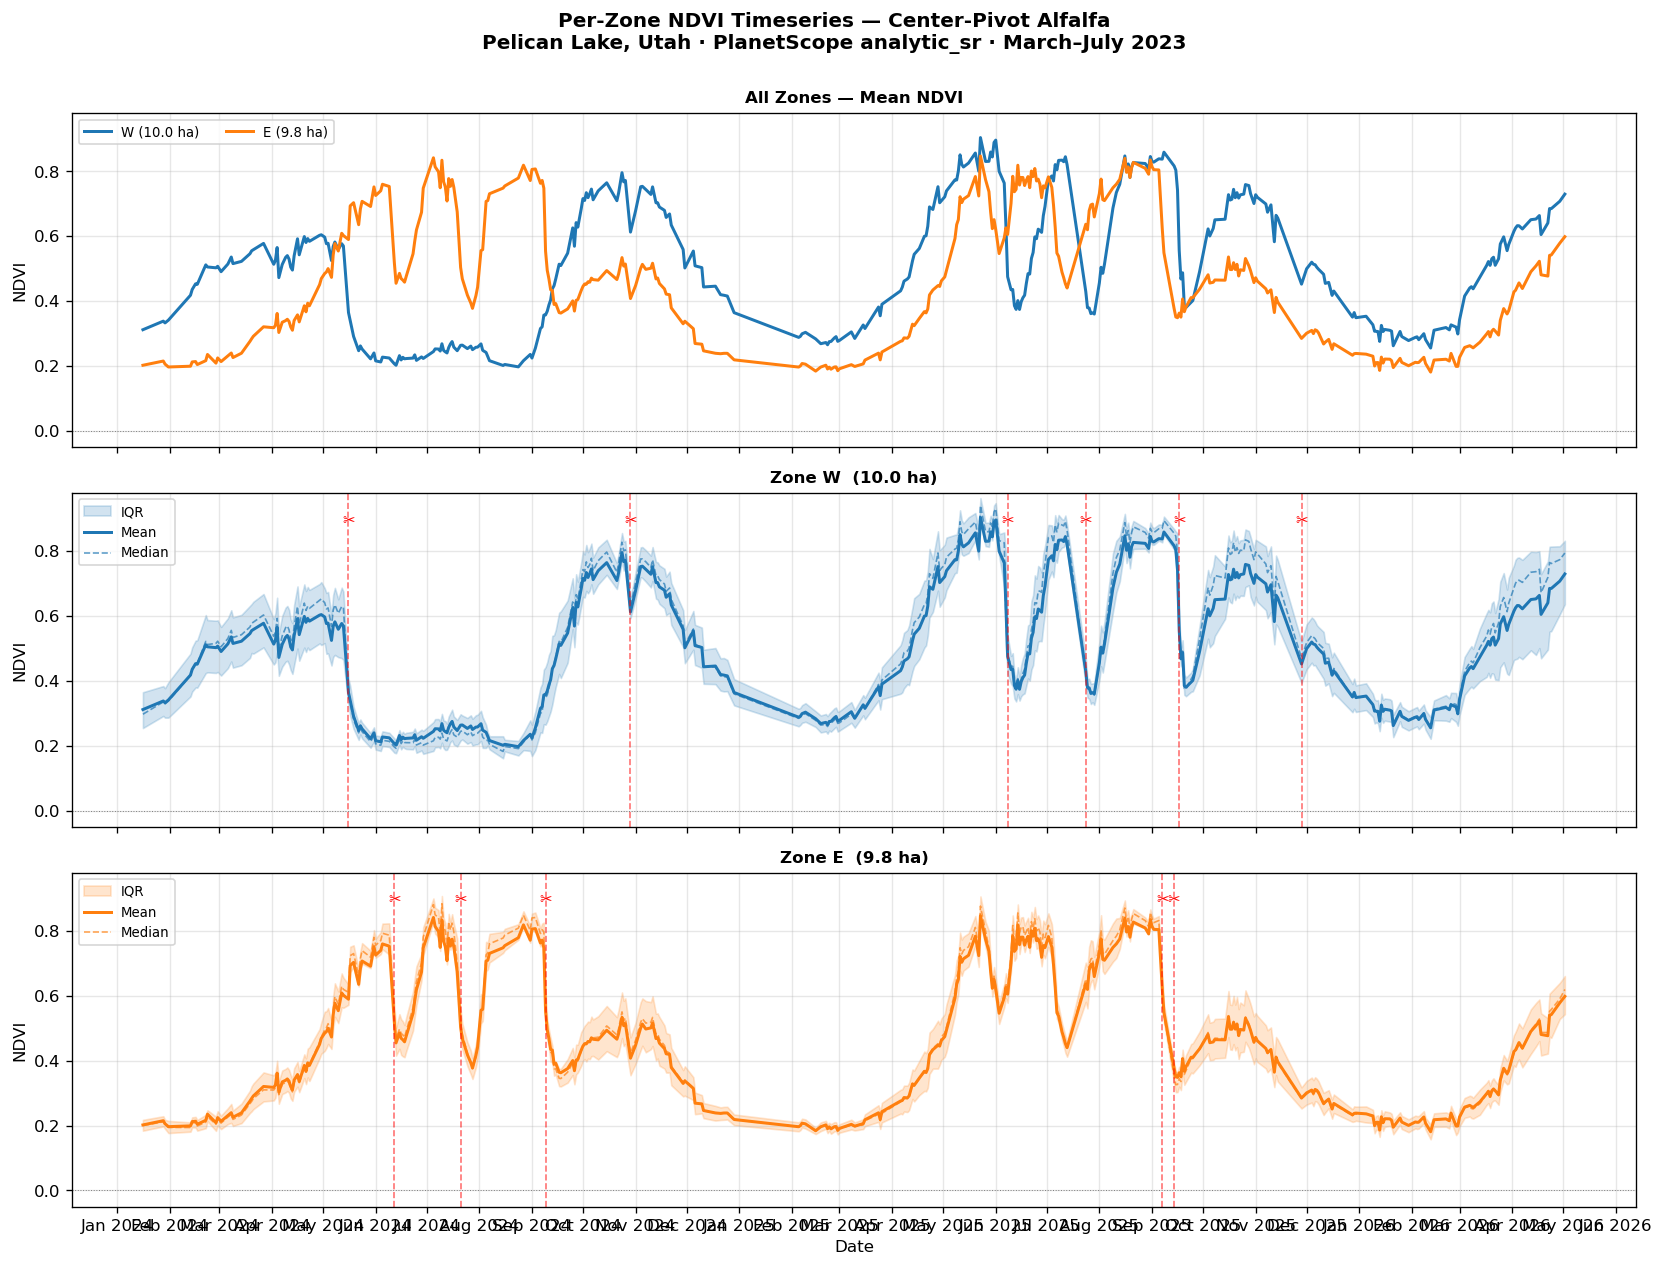

Saved → ndvi_timeseries_by_zone.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def annotate_cuts(ax, series, y_label=0.88, min_drop=0.15, min_prev=0.40):
    """Mark probable cutting events as red dashed vertical lines."""
    vals  = series.dropna().values
    dates = series.dropna().index
    for i in range(1, len(vals)):
        drop = vals[i-1] - vals[i]
        if drop >= min_drop and vals[i-1] >= min_prev:
            ax.axvline(dates[i], color='red', lw=1.0, alpha=0.55, ls='--')
            ax.text(dates[i], y_label, '✂', fontsize=9,
                    color='red', ha='center', va='top')


# Prepare per-zone long-format data for plotting
zone_ts = {}
for z in zone_names:
    zdf = df_best[df_best['zone'] == z].set_index('date').sort_index()
    zdf.index = pd.DatetimeIndex(zdf.index)
    zone_ts[z] = zdf

# --- AUTOMATIC COLOR SELECTION ---
# Uses 'tab10' for up to 10 zones, or scales to 'tab20' if you have more.
cmap = plt.colormaps['tab10'] if len(zone_names) <= 10 else plt.colormaps['tab20']
dynamic_colors = {z: cmap(i % cmap.N) for i, z in enumerate(zone_names)}
# ---------------------------------

fig, axes = plt.subplots(len(zone_names) + 1, 1,
                         figsize=(14, 3.5 * (len(zone_names) + 1)),
                         sharex=True)
fig.suptitle(
    'Per-Zone NDVI Timeseries — Center-Pivot Alfalfa\n'
    'Pelican Lake, Utah · PlanetScope analytic_sr · March–July 2023',
    fontsize=12, fontweight='bold', y=1.001
)

# Top panel: all zones on one plot for comparison
ax0 = axes[0]
for z in zone_names:
    zdf = zone_ts[z]
    col = dynamic_colors[z]  # Automatically assigned color
    ax0.plot(zdf.index, zdf['ndvi_mean'], color=col, lw=1.8, label=f'{z} ({zones[z]["area_ha"]:.1f} ha)')

ax0.set_ylabel('NDVI', fontsize=10)
ax0.set_ylim(-0.05, 0.98)
ax0.legend(fontsize=8, ncol=len(zone_names), loc='upper left')
ax0.set_title('All Zones — Mean NDVI', fontsize=10, fontweight='bold')
ax0.grid(True, alpha=0.3)
ax0.axhline(0, color='gray', lw=0.6, ls=':')

# Individual zone panels
for ax, z in zip(axes[1:], zone_names):
    zdf = zone_ts[z]
    col = dynamic_colors[z]  # Automatically assigned color

    ax.fill_between(zdf.index, zdf['ndvi_p25'], zdf['ndvi_p75'],
                    color=col, alpha=0.20, label='IQR')
    ax.plot(zdf.index, zdf['ndvi_mean'],   color=col, lw=1.8, label='Mean')
    ax.plot(zdf.index, zdf['ndvi_median'], color=col, lw=1.0, ls='--', alpha=0.7, label='Median')

    annotate_cuts(ax, zdf['ndvi_mean'], y_label=0.92)

    ax.set_ylabel('NDVI', fontsize=10)
    ax.set_ylim(-0.05, 0.98)
    ax.set_title(f'Zone {z}  ({zones[z]["area_ha"]:.1f} ha)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.6, ls=':')

axes[-1].set_xlabel('Date', fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
for ax in axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{stationid}_ndvi_timeseries_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ndvi_timeseries_by_zone.png')

## 9 · Estimated Alfalfa Height by Zone

In [ ]:
# --- AUTOMATIC COLOR SELECTION ---

# Uses 'tab10' for up to 10 zones, or scales to 'tab20' if you have more.
cmap = plt.colormaps['tab10'] if len(zone_names) <= 10 else plt.colormaps['tab20']
dynamic_colors = {z: cmap(i % cmap.N) for i, z in enumerate(zone_names)}
# ---------------------------------

fig, axes = plt.subplots(len(zone_names) + 1, 1,
                         figsize=(14, 3.5 * (len(zone_names) + 1)),
                         sharex=True)
fig.suptitle(
    f'Estimated Alfalfa Canopy Height by Zone\n'
    f'Model: H = {HEIGHT_SLOPE:.0f}×NDVI + {HEIGHT_INTERCEPT:.0f} cm',
    fontsize=12, fontweight='bold', y=1.001
)

# Reference lines
ref_heights = [(75, 'pre-cut ~75 cm'), (10, 'post-cut ~10 cm')]

# Top panel: all zones
ax0 = axes[0]
for z in zone_names:
    zdf = zone_ts[z]
    col = dynamic_colors[z]  # Automatically assigned color
    ax0.plot(zdf.index, zdf['height_mean_cm'], color=col, lw=1.8,
             label=f'{z} ({zones[z]["area_ha"]:.1f} ha)')

for h, lbl in ref_heights:
    ax0.axhline(h, color='gray', lw=0.8, ls=':', alpha=0.7)

ax0.set_ylabel('Height (cm)', fontsize=10)
ax0.set_ylim(-2, 100)
ax0.legend(fontsize=8, ncol=len(zone_names), loc='upper left')
ax0.set_title('All Zones — Mean Estimated Height', fontsize=10, fontweight='bold')
ax0.grid(True, alpha=0.3)

# Individual zone panels
for ax, z in zip(axes[1:], zone_names):
    zdf = zone_ts[z]
    col = dynamic_colors[z]  # Automatically assigned color

    ax.fill_between(zdf.index, zdf['height_p25_cm'], zdf['height_p75_cm'],
                    color=col, alpha=0.20, label='IQR')
    ax.plot(zdf.index, zdf['height_mean_cm'],   color=col, lw=1.8, label='Mean')
    ax.plot(zdf.index, zdf['height_median_cm'], color=col, lw=1.0, ls='--', alpha=0.7, label='Median')

    annotate_cuts(ax, zdf['ndvi_mean'], y_label=92)

    for h, lbl in ref_heights:
        ax.axhline(h, color='gray', lw=0.7, ls=':', alpha=0.6)
        ax.text(zdf.index[0], h + 2, lbl, fontsize=7, color='gray')

    ax.set_ylabel('Height (cm)', fontsize=10)
    ax.set_ylim(-2, 100)
    ax.set_title(f'Zone {z}  ({zones[z]["area_ha"]:.1f} ha)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
for ax in axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{stationid}_height_timeseries_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → height_timeseries_by_zone.png')

## 10 · Zone Comparison Heatmap
A date × zone heatmap makes it easy to spot which zones are ahead or behind in the growth cycle.

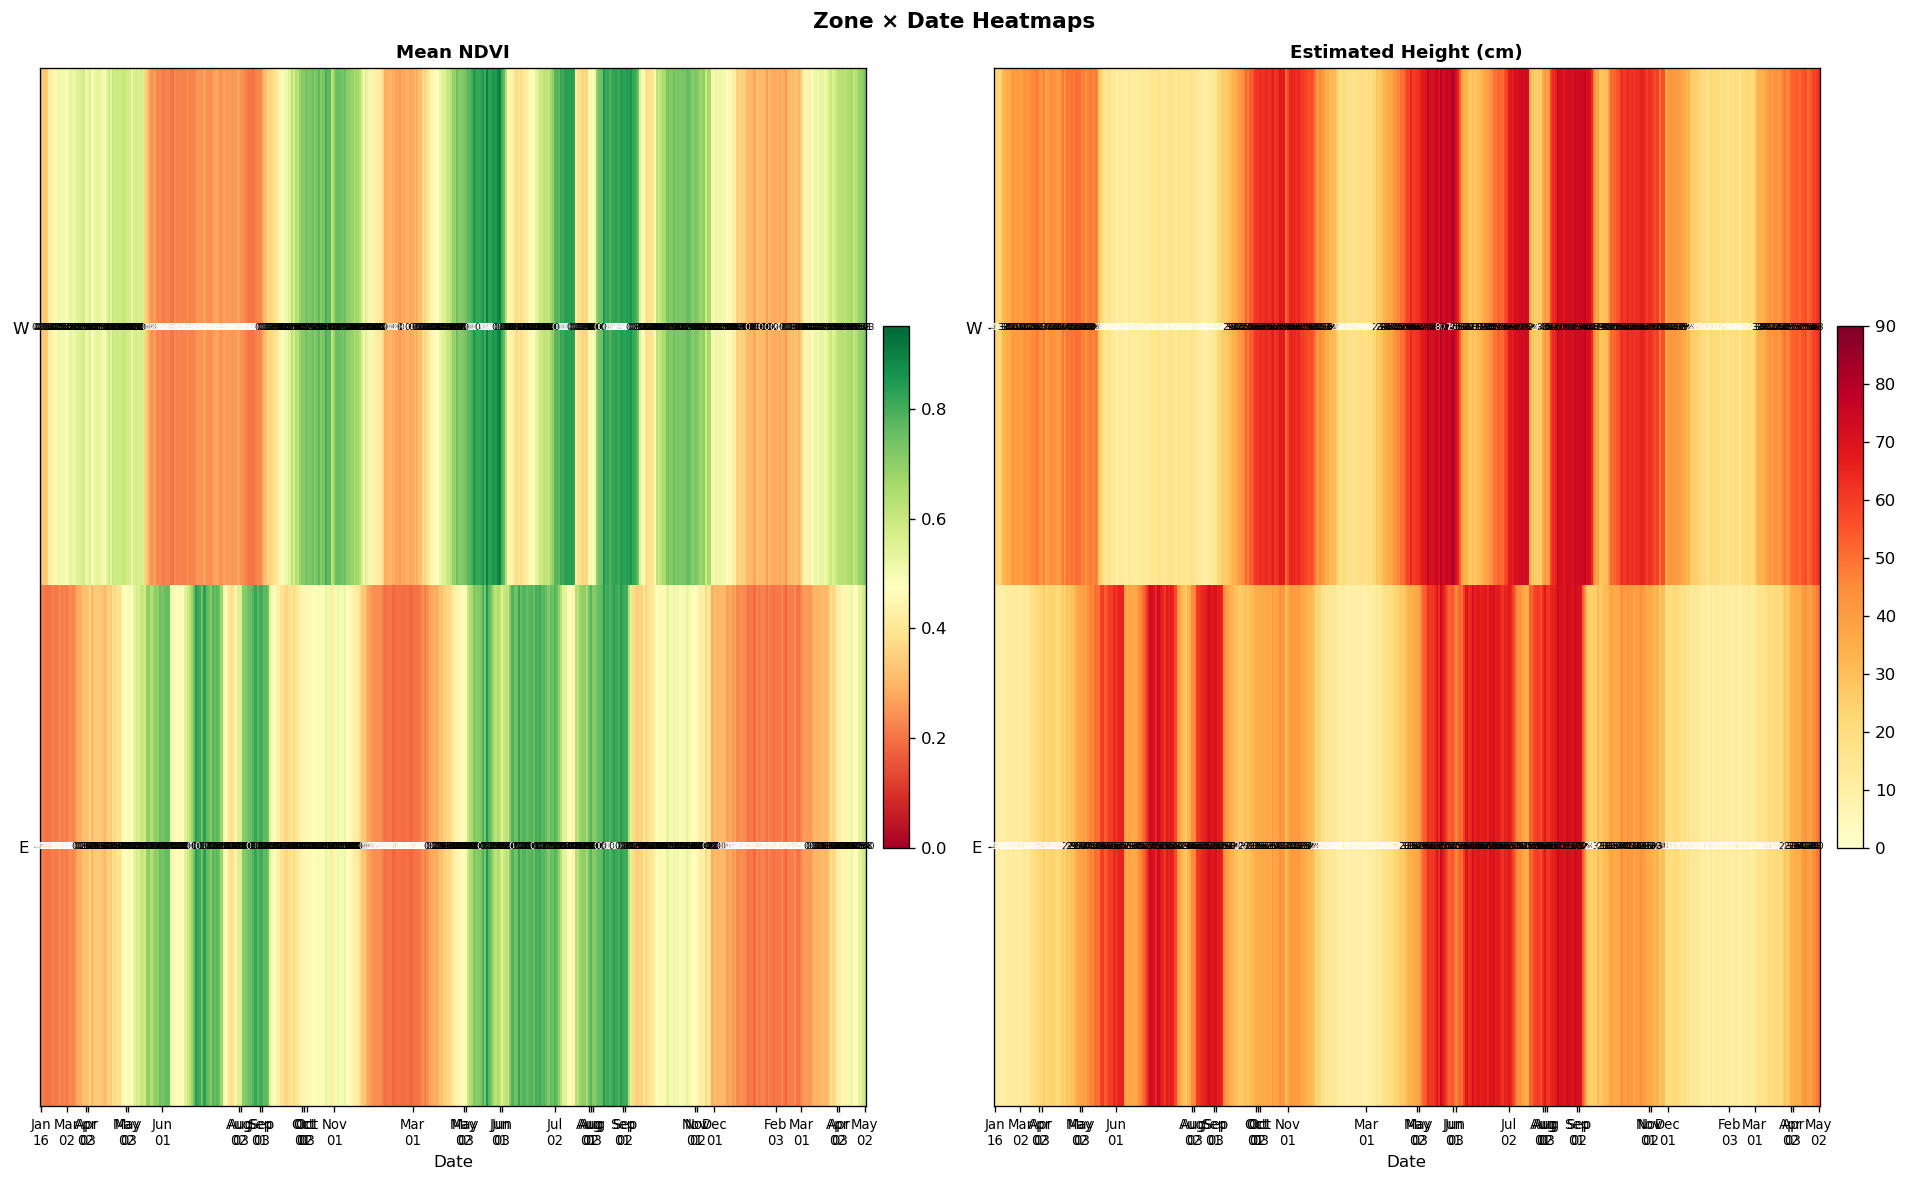

Saved → zone_heatmap.png


In [11]:
# Build a matrix: rows = dates, columns = zones
ndvi_matrix = pd.DataFrame(
    {z: zone_ts[z]['ndvi_mean'] for z in zone_names}
).sort_index()

height_matrix = pd.DataFrame(
    {z: zone_ts[z]['height_mean_cm'] for z in zone_names}
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Zone × Date Heatmaps', fontsize=13, fontweight='bold')

for ax, mat, title, cmap, vmin, vmax, fmt in [
    (axes[0], ndvi_matrix,   'Mean NDVI',              'RdYlGn', 0.0, 0.95, '.2f'),
    (axes[1], height_matrix, 'Estimated Height (cm)',  'YlOrRd', 0,   90,   '.0f'),
]:
    im = ax.imshow(mat.values.T, aspect='auto', cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

    # Axis ticks
    ax.set_yticks(range(len(zone_names)))
    ax.set_yticklabels(zone_names, fontsize=10)

    # X-axis: show monthly ticks
    date_idx = mat.index
    tick_positions = [i for i, d in enumerate(date_idx)
                      if d.day <= 3 or i == 0 or i == len(date_idx) - 1]
    tick_labels    = [date_idx[i].strftime('%b\n%d') for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Annotate each cell with value
    for yi, zone in enumerate(zone_names):
        for xi, val in enumerate(mat[zone].values):
            if not np.isnan(val):
                ax.text(xi, yi, format(val, fmt),
                        ha='center', va='center', fontsize=5.5,
                        color='black' if vmin + (vmax-vmin)*0.3 < val < vmin + (vmax-vmin)*0.85 else 'white')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{stationid}_zone_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → zone_heatmap.png')

## 11 · Detect Cutting Events Per Zone

In [14]:
CUT_DROP_THRESHOLD = 0.12   # minimum NDVI drop to flag as a cut
CUT_MIN_PREV_NDVI  = 0.40   # must have been at least this green before the drop

cut_events = []

for z in zone_names:
    zdf = zone_ts[z].sort_index()
    ndvi_series = zdf['ndvi_mean'].dropna()
    vals  = ndvi_series.values
    dates = ndvi_series.index

    for i in range(1, len(vals)):
        drop = vals[i-1] - vals[i]
        if drop >= CUT_DROP_THRESHOLD and vals[i-1] >= CUT_MIN_PREV_NDVI:
            cut_events.append({
                'zone'         : z,
                'cut_date'     : dates[i].date(),
                'ndvi_before'  : round(vals[i-1], 3),
                'ndvi_after'   : round(vals[i],   3),
                'ndvi_drop'    : round(drop, 3),
                'height_before': round(HEIGHT_SLOPE * vals[i-1] + HEIGHT_INTERCEPT, 1),
                'height_after' : round(HEIGHT_SLOPE * vals[i]   + HEIGHT_INTERCEPT, 1),
                'days_gap'     : (dates[i] - dates[i-1]).days,
            })

df_cuts = pd.DataFrame(cut_events)
if df_cuts.empty:
    print('No cutting events detected with current thresholds.')
else:
    print(f'Detected {len(df_cuts)} cutting event(s):\n')
    print(df_cuts.to_string(index=False))

Detected 12 cutting event(s):

zone   cut_date  ndvi_before  ndvi_after  ndvi_drop  height_before  height_after  days_gap
   W 2024-05-16        0.570       0.365      0.205           47.0          26.5         3
   W 2024-10-29        0.772       0.613      0.159           67.2          51.3         3
   W 2025-06-07        0.764       0.631      0.133           66.4          53.1         1
   W 2025-06-08        0.631       0.475      0.156           53.1          37.5         1
   W 2025-07-24        0.820       0.429      0.391           72.0          32.9        11
   W 2025-09-17        0.742       0.556      0.186           64.2          45.6         1
   W 2025-11-28        0.656       0.452      0.204           55.6          35.2        14
   E 2024-06-12        0.753       0.518      0.235           65.3          41.8         3
   E 2024-07-21        0.675       0.504      0.171           57.5          40.4         2
   E 2024-09-09        0.748       0.554      0.194        

## 12 · Summary Statistics Table

In [15]:
summary_rows = []
for z in zone_names:
    zdf = zone_ts[z]
    ndvi = zdf['ndvi_mean'].dropna()
    h    = zdf['height_mean_cm'].dropna()
    summary_rows.append({
        'Zone'              : z,
        'Area (ha)'         : round(zones[z]['area_ha'], 1),
        'N dates'           : len(ndvi),
        'NDVI min'          : round(ndvi.min(), 3),
        'NDVI max'          : round(ndvi.max(), 3),
        'NDVI mean'         : round(ndvi.mean(), 3),
        'NDVI peak date'    : ndvi.idxmax().strftime('%Y-%m-%d'),
        'Height min (cm)'   : round(h.min(), 1),
        'Height max (cm)'   : round(h.max(), 1),
        'Height peak date'  : h.idxmax().strftime('%Y-%m-%d'),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Zone')
print('Per-zone season summary:')
df_summary

Per-zone season summary:


,Area (ha),N dates,NDVI min,NDVI max,NDVI mean,NDVI peak date,Height min (cm),Height max (cm),Height peak date
Zone,,,,,,,,,
W,10.0,389,0.197,0.904,0.512,2025-05-23,9.7,80.4,2025-05-23
E,9.8,389,0.181,0.847,0.470,2025-05-23,8.1,74.7,2025-05-23


## 13 · Export Results to CSV

In [16]:
# Long-format CSV: one row per (date, zone)
df_long = df_best.copy()
df_long['date'] = df_long['date'].dt.strftime('%Y-%m-%d')
long_path = OUTPUT_DIR / f'{stationid}_pivot_ndvi_multizone_long.csv'
df_long.to_csv(long_path, index=False)
print(f'Long-format CSV saved → {long_path}')

# Wide-format CSV: one row per date, columns per zone
df_wide_export = df_wide.copy()
df_wide_export.index = df_wide_export.index.strftime('%Y-%m-%d')
wide_path = OUTPUT_DIR / f'{stationid}_pivot_ndvi_multizone_wide.csv'
df_wide_export.to_csv(wide_path)
print(f'Wide-format CSV saved → {wide_path}')

# Summary CSV
df_summary.to_csv(OUTPUT_DIR / f'{stationid}_pivot_zone_summary.csv')
print(f'Summary CSV saved     → pivot_zone_summary.csv')

# Cut events CSV
if not df_cuts.empty:
    df_cuts.to_csv(OUTPUT_DIR / f'{stationid}_pivot_cut_events.csv', index=False)
    print(f'Cut events CSV saved  → pivot_cut_events.csv')

print('\nAll outputs written to:', OUTPUT_DIR.resolve())

Long-format CSV saved → US-UTJ_pivot_ndvi_multizone_long.csv
Wide-format CSV saved → US-UTJ_pivot_ndvi_multizone_wide.csv
Summary CSV saved     → pivot_zone_summary.csv
Cut events CSV saved  → pivot_cut_events.csv

All outputs written to: M:\Shared drives\UGS_Flux\Data_Processing\Jupyter_Notebooks\crop_height\ndvi_analysis
